# Campaña de Marketing Bancario

### Estructura del Notebook

 1. Carga del conjunto de datos
 2. Análisis Exploratorio de Datos (EDA)
 3. Modelo de Regresión Logística (Baseline)
 4. Optimización del Modelo

## 1.	Carga del conjunto de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Carga del dataset
df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv',
    sep=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


El dataset tiene un total de 41.188 filas y 21 columnas, en los que vemos que hay datos de clientes de un banco a los que se les ha contactado para ofrecerles una campaña.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Podemos apreciar que no hay valores nulos en el dataset y los tipos de valores que almacena.

In [ ]:
# Tipos de datos
df.dtypes


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


Este dataset almacena tres tipos de datos `int`, `float` y `object`.

In [ ]:
# Valores nulos
print('Valores nulos:')
print(df.isnull().sum())

Valores nulos:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Confirmamos que no hay ningun valor nulo en el dataset.

## 2. Análisis Exploratorio de Datos (EDA)

In [ ]:
# Este dataset no tiene NaN, pero sí tiene 'unknown' en columnas categóricas
# Cuántos 'unknown' hay en cada columna
cat_cols = df.select_dtypes(include='object').columns

print('Valores unknown por columna:')
for col in cat_cols:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f'  {col}: {unk} ({unk/len(df)*100:.1f}%)')

Valores unknown por columna:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


**Qué hacer con los 'unknown':**

Hay columnas como `job`, `marital` o `education` con valores desconocidos.Busacre uan forma de tratarlos pero no los puedo eliminar porque perderíamos demasiadas filas.

In [ ]:
print('Distribución de la variable objetivo (y):')
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de la variable objetivo (y):
y
no     36548
yes     4640
Name: count, dtype: int64

y
no     88.7%
yes    11.3%
Name: proportion, dtype: object


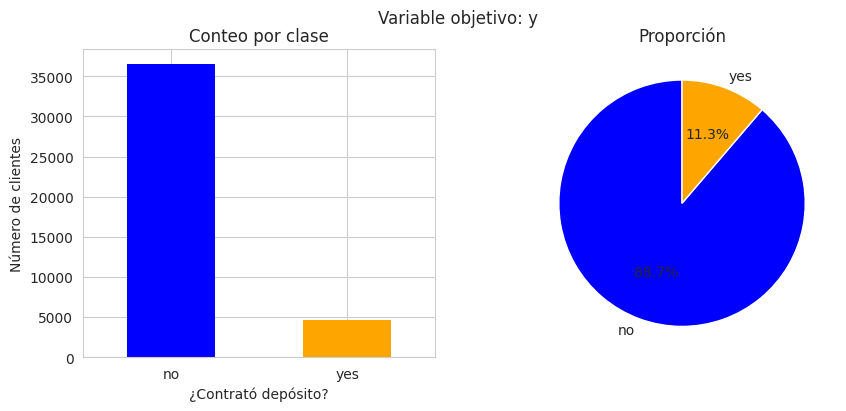

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barras
df['y'].value_counts().plot(kind='bar',
                            ax=axes[0],
                            color=['blue', 'orange'],
                            edgecolor='none', rot=0)
axes[0].set_title('Conteo por clase')
axes[0].set_xlabel('¿Contrató depósito?')
axes[0].set_ylabel('Número de clientes')

# Tarta
df['y'].value_counts().plot(kind='pie',
                            ax=axes[1],
                            autopct='%1.1f%%',
                            colors=['blue', 'orange'],
                            startangle=90)
axes[1].set_title('Proporción')
axes[1].set_ylabel('')

plt.suptitle('Variable objetivo: y')
plt.show()

**Análisis:**

Hay un **contraste importante**: casi el 90% de los clientes dijo que no frente a un 11% que dijo que sí. Esto puede ser un problema para el modelo, porque si predice siempre "no" ya acertaría el casi el 90% de las veces pero sería inútil para el banco.

In [ ]:
# Variables numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Variables numéricas: {num_cols}')
#Separo las variables numéricas de las categóricas.

Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


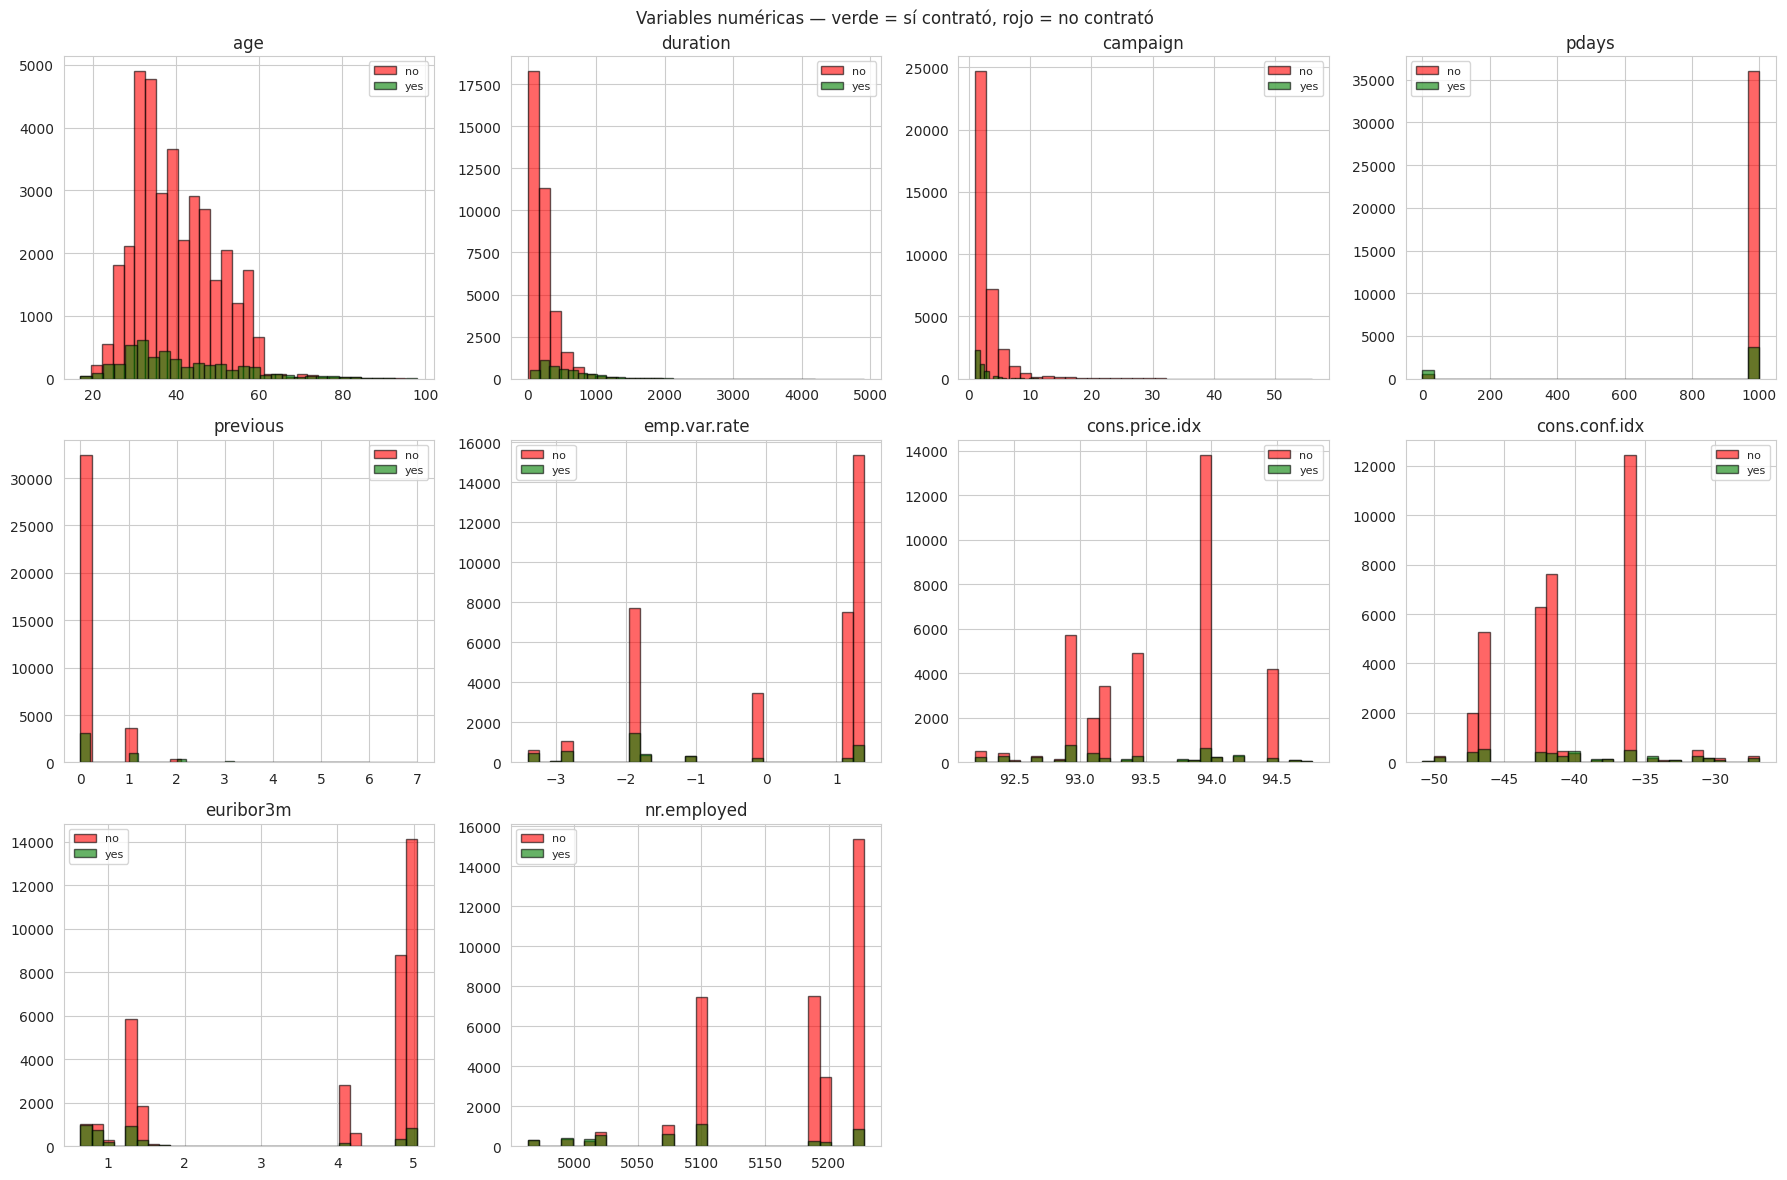

In [ ]:
# Histograma de cada variable numérica separado por clase (yes/no)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, color in zip(['no', 'yes'], ['red', 'green']):
        axes[i].hist(df[df['y'] == val][col],
                     bins=30,
                     alpha=0.6,
                     color=color,
                     label=val,
                     edgecolor='black')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Ocultar los ejes que sobren
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)


plt.suptitle('Variables numéricas — verde = sí contrató, rojo = no contrató')
plt.tight_layout()
plt.show()

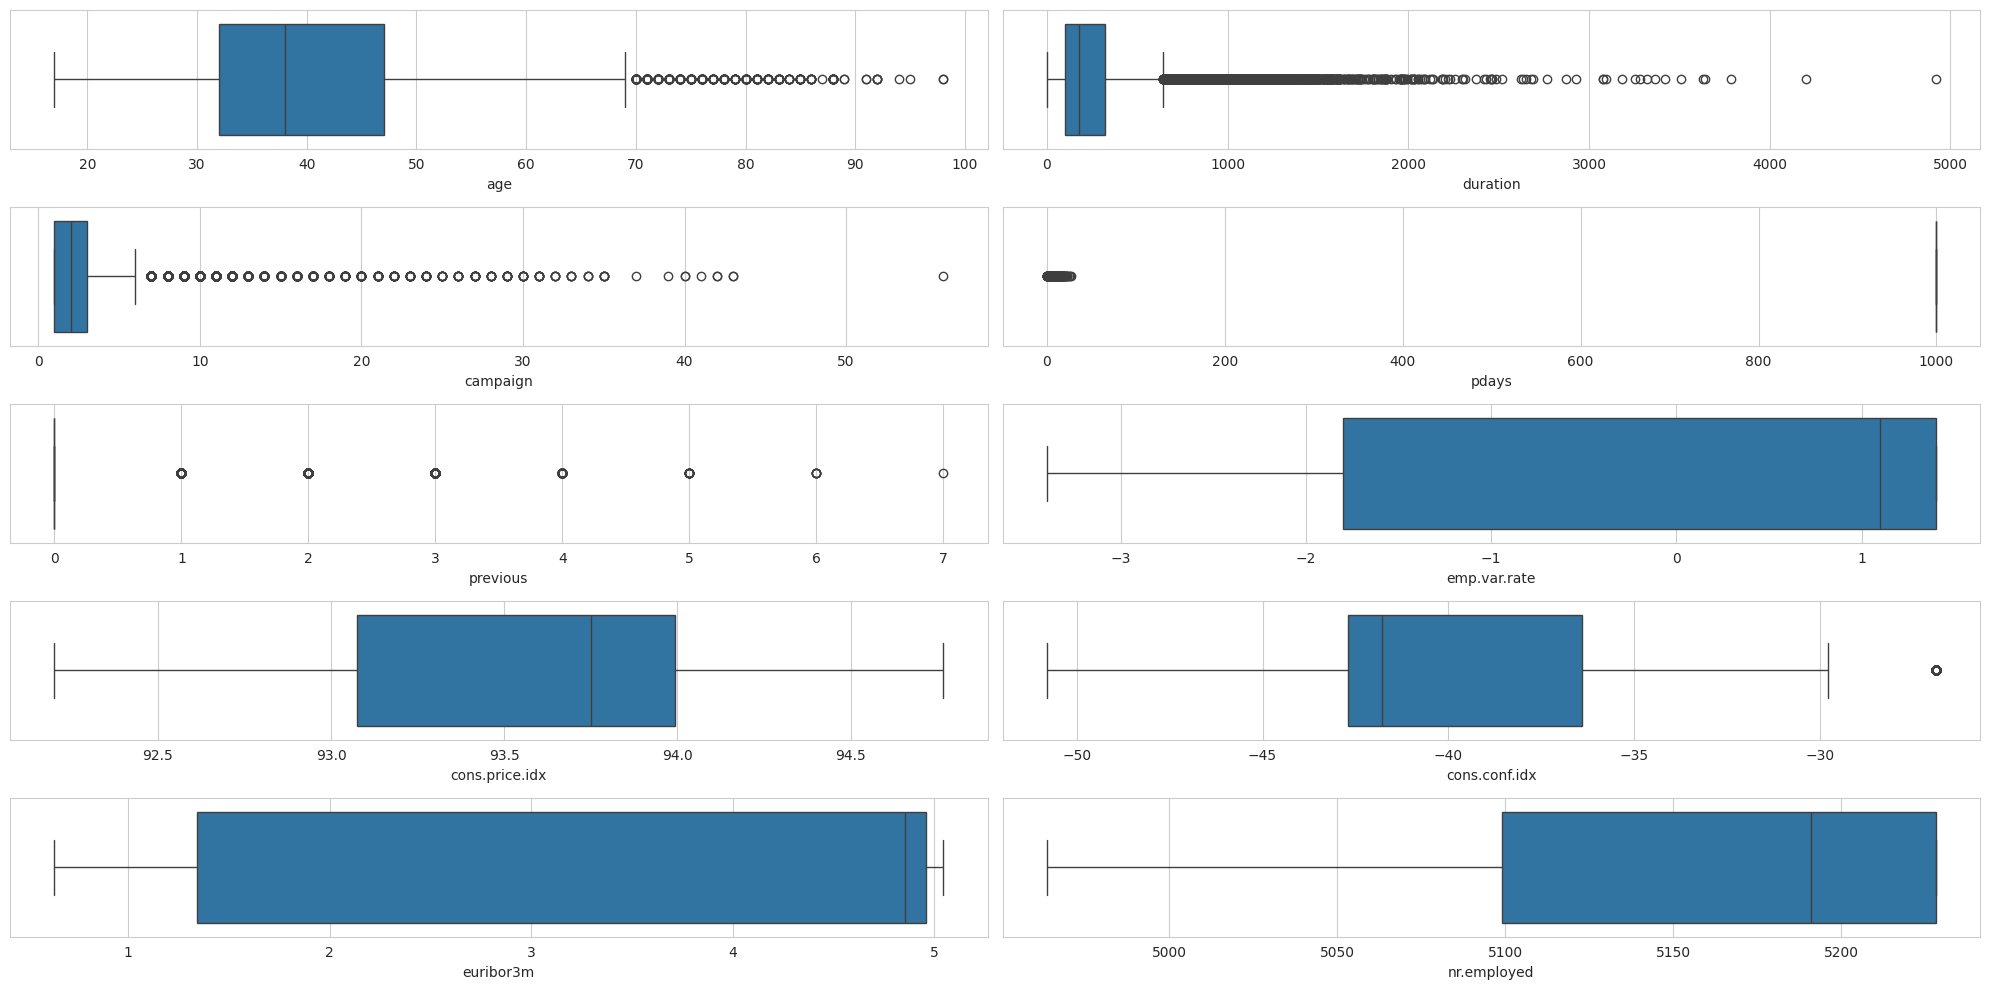

In [ ]:
fig, axis = plt.subplots(5, 2, figsize=(20, 10))

# Creo una figura multiple boxplot
sns.set_style('whitegrid')
sns.boxplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[0, 1], data=df, x='duration')
sns.boxplot(ax=axis[1, 0], data=df, x='campaign')
sns.boxplot(ax=axis[1, 1], data=df, x='pdays')
sns.boxplot(ax=axis[2, 0], data=df, x='previous')
sns.boxplot(ax=axis[2, 1], data=df, x='emp.var.rate')
sns.boxplot(ax=axis[3, 0], data=df, x='cons.price.idx')
sns.boxplot(ax=axis[3, 1], data=df, x='cons.conf.idx')
sns.boxplot(ax=axis[4, 0], data=df, x='euribor3m')
sns.boxplot(ax=axis[4, 1], data=df, x='nr.employed')

plt.tight_layout()
plt.show()

**Análisis:**

- **`duration`** es la variable que más diferencia a los dos grupos. Los que sí contrataron tienen llamadas mucho más largas. Sin embargo, esta variable tiene trampa: solo sabemos la duración *después* de hacer la llamada.
- **`euribor3m`** y **`nr.employed`** separa bien las clases pero están muy correlacionadas entre sí, solo puedo elegir una.
- **`pdays`** tiene un valor especial: 999 significa que nunca se contactó al cliente. Lo convierto en una variable binaria.


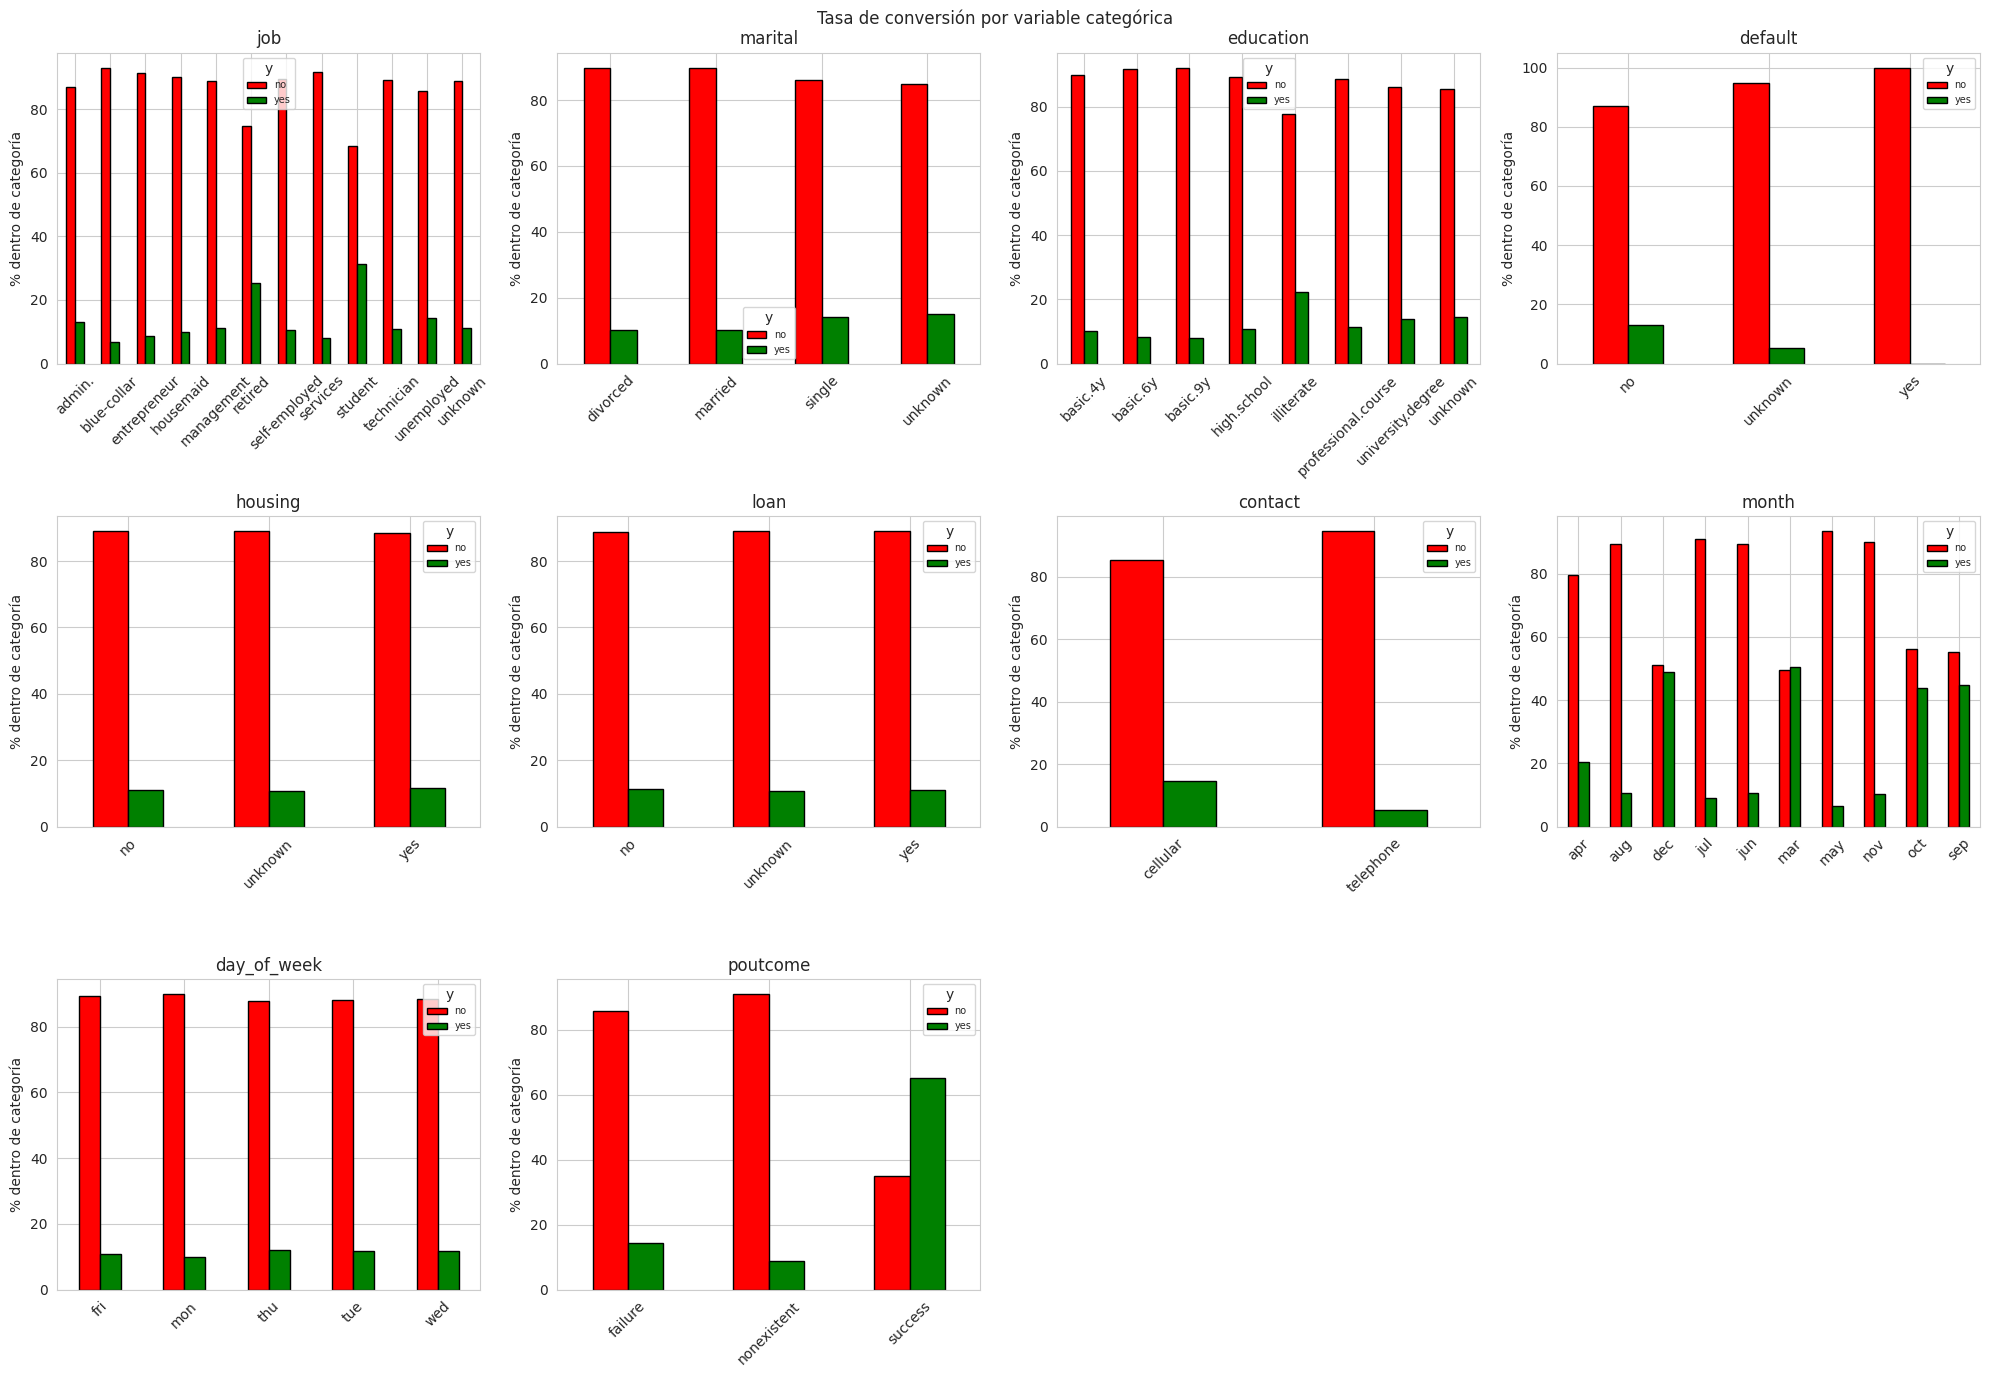

In [ ]:
# Variables categóricas
cat_feat = [c for c in df.select_dtypes(include='object').columns if c != 'y']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
# Calcula el % de 'yes' dentro de cada categoría
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar',
            ax=axes[i],
            color=['red', 'green'],
            edgecolor='black',
            rot=45)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% dentro de categoría')
    axes[i].legend(title='y', fontsize=7)

# Ocultar los ejes que sobren
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de conversión por variable categórica')
plt.tight_layout()
plt.show()

**Análisis:**

- **`contact`**: los clientes contactados al móvil contratan más que los que han sido contactados al teléfono fijo.
- **`month`**: hay meses con tasas de contratación mucho más altas. Las campañas tienen mejor efecto unos meses que otros.
- **`poutcome`**  si el cliente ya contrató una campaña, la probabilidad de que lo vuelva a hacer es altísima.
- **`job`**: jubilados y estudiantes tienen tasas de contrartación por encima de la media.

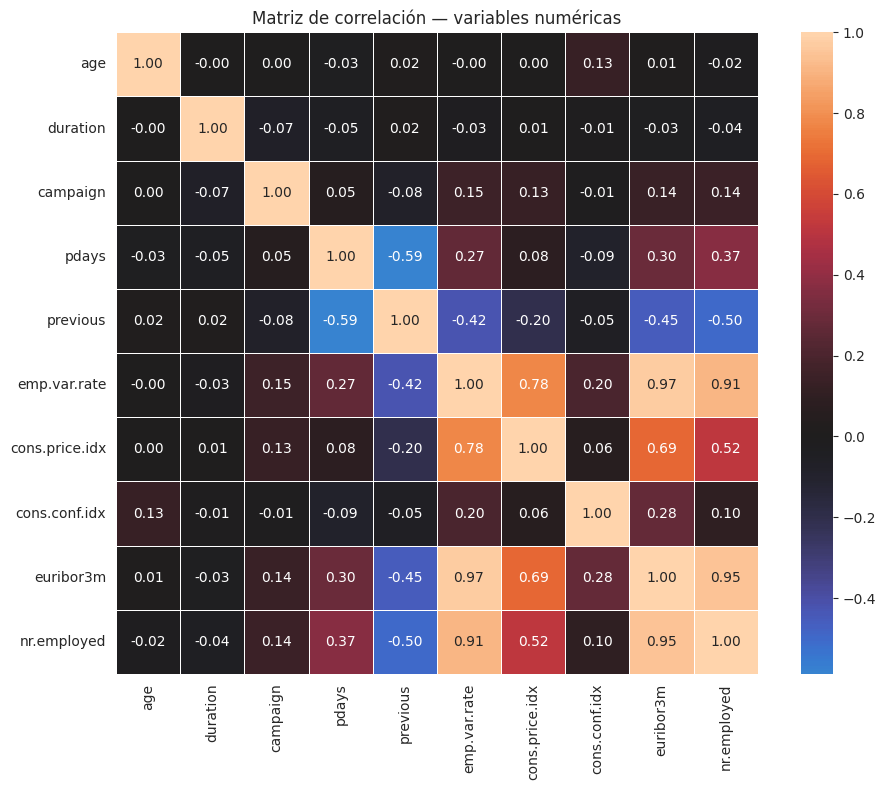

In [ ]:
# Matriz de correllación
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

**Análisis:**

Hay varias variables relacionadas entre sí: `euribor3m`, `nr.employed` y `emp.var.rate` miden parametros parecidos, son indicadores económicos y se correlacionan fuertemente. Dejar todas en el modelo no añade mucha información nueva. Esto confirma que tengo que eliminar `euribor3m` y `nr.employed`.

## 3. Preparación de datos

Antes de entrenar el modelo hay que:
1. Eliminar columnas problemáticas
2. Tratar los 'unknown'
3. Transformar `pdays`
4. Codificar variables categóricas
5. Dividir en train/test
6. Escalar

In [ ]:
df_model = df.copy()

# 1. Elimino columnas con multicolinealidad
df_model.drop(columns=['duration', 'euribor3m', 'nr.employed'], inplace=True)
print('Columnas eliminadas: duration, euribor3m, nr.employed')
print(f'Columnas restantes: {df_model.shape[1]}')

Columnas eliminadas: duration, euribor3m, nr.employed
Columnas restantes: 18


In [ ]:
# 2. Reemplazo 'unknown' por la moda de cada columna
cat_feat = [c for c in df_model.select_dtypes(include='object').columns if c != 'y']

for col in cat_feat:
    moda = df_model[col][df_model[col] != 'unknown'].mode()[0]
    df_model[col] = df_model[col].replace('unknown', moda)


In [ ]:
# 3. pdays = 999 significa "no contactado antes" lo convierto en 0/1
df_model['previously_contacted'] = (df_model['pdays'] != 999).astype(int)
df_model.drop(columns=['pdays'], inplace=True)

print('✔ pdays convertida en previously_contacted (0 = nunca, 1 = sí contactado antes)')
print(df_model['previously_contacted'].value_counts())


✔ pdays convertida en previously_contacted (0 = nunca, 1 = sí contactado antes)
previously_contacted
0    39673
1     1515
Name: count, dtype: int64


In [ ]:
# 4. Codifico las variables categóricas con get_dummies
cat_feat = [c for c in df_model.select_dtypes(include='object').columns if c != 'y']
df_model = pd.get_dummies(df_model, columns=cat_feat, drop_first=True, dtype=int)

# Variable objetivo: convertimos yes/no a 1/0
df_model['y'] = (df_model['y'] == 'yes').astype(int)

print(f'Shape final: {df_model.shape}')

Shape final: (41188, 45)


In [ ]:
# 5. Separo X e y. Dividimos en train/test
X = df_model.drop(columns=['y'])
y = df_model['y']

# stratify=y mantiene la misma proporción yes/no en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=128, stratify=y)

print(f'Train: {X_train.shape[0]:,} filas  — {y_train.mean()*100:.1f}% positivos')
print(f'Test:  {X_test.shape[0]:,} filas  — {y_test.mean()*100:.1f}% positivos')

Train: 28,831 filas  — 11.3% positivos
Test:  12,357 filas  — 11.3% positivos


In [ ]:
# 6. Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


## 4. Modelo de Regresión Logística — Baseline

In [ ]:
# Entrenamiento del modelo
logmodel = LogisticRegression(max_iter=2000, random_state=128)
logmodel.fit(X_train_sc, y_train)

# Predicciones
predictions = logmodel.predict(X_test_sc)
y_prob = logmodel.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, predictions, target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.91      0.99      0.95     10965
         yes       0.66      0.23      0.34      1392

    accuracy                           0.90     12357
   macro avg       0.79      0.61      0.65     12357
weighted avg       0.88      0.90      0.88     12357



**Anlisis:**

El recall para `no` es muy alto, esto me hace pensar que el módelo dará como resultado `no` en muchas ocasiones, más de las que debería, aunque en los datos originales el `no` ya es muy abundante.



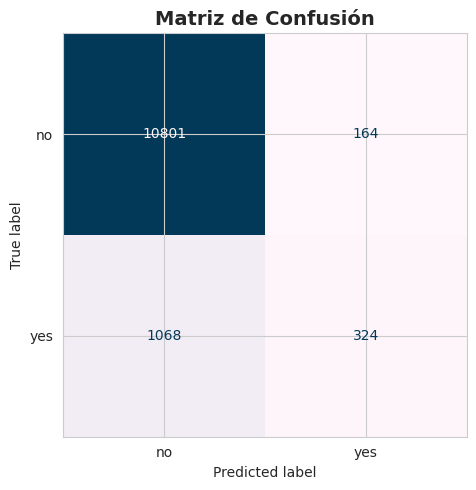

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, predictions),
    display_labels=['no', 'yes']
).plot(ax=ax, colorbar=False, cmap='PuBu')

ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Optimización del Modelo

El problema del baseline es el **desbalanceo** (89% no / 11% sí). Investigando vi que la solución más sencilla es usar `class_weight='balanced'`, que le dice al modelo que penalice más los errores en la clase minoritaria (yes).

In [ ]:
# Modelo optimizado
logmodel_opt = LogisticRegression(
    max_iter=2000,
    random_state=128,
    class_weight='balanced',  # Corrige el desbalanceo
    C=0.1                     # Regulariza más
)
logmodel_opt.fit(X_train_sc, y_train)

predictions_opt = logmodel_opt.predict(X_test_sc)
y_prob_opt = logmodel_opt.predict_proba(X_test_sc)[:, 1]

print('Classification Report (optimizado):')
print(classification_report(y_test, predictions_opt, target_names=['no', 'yes']))

Classification Report (optimizado):
              precision    recall  f1-score   support

          no       0.95      0.85      0.90     10965
         yes       0.35      0.63      0.45      1392

    accuracy                           0.83     12357
   macro avg       0.65      0.74      0.67     12357
weighted avg       0.88      0.83      0.85     12357



#**Conclusiones del ejercicio**

1. Carga conjunto de datos:
El dataset tiene 41.188 clientes con 21 variables. Lo más destacado del EDA es el desbalanceo severo en la variable objetivo: el 88.7% de los clientes no contrató el depósito y solo el 11.3% sí lo hizo. Este desequilibrio es el principal problema del ejercicio porque condiciona todas las decisiones del modelo.

2. Análisis Exploratorio de Datos (EDA):
Se tomaron decisiones clave en la preparación:
`duration` se eliminó porque solo se conoce después de la llamada, lo que la haría inútil en producción real (data leakage).
`euribor3m` y `nr.employed` se eliminaron por alta multicolinealidad con `emp.var.rate` (todos son indicadores macroeconómicos correlacionados).
`pdays` se transformó en una variable binaria `previously_contacted` (0/1), ya que el valor 999 tenía un significado especial ("nunca contactado").
Los valores unknown se imputaron con la moda, evitando perder filas.

3. Comparativa de modelos:
MétricaBaselineOptimizado (class_weight='balanced')Recall (yes)23%63%Precision (yes)66%35%F1-score (yes)0.340.45Accuracy global90%83%

4. Lo más importante: accuracy no lo es todo:
El modelo baseline tiene un 90% de accuracy, en principio parece muy bueno, pero es engañoso: porque siempre predecía "no" y se perdía el 77% de los clientes realmente interesados. Esto muestra perfectamente por qué en datasets desbalanceados hay que mirar recall, precision y F1, no solo accuracy.

5. ¿Qué modelo conviene al banco?:
El modelo optimizado (con class_weight='balanced' y C=0.1) es el más útil para el negocio. Detecta el 63% de los clientes que sí van a contratar, a costa de generar más falsos positivos. En el contexto de una campaña de marketing, es preferible llamar a  más clientes que perder a la mayoría de los interesados.
